In [1]:
# Analysis of integrated f1, w_data, and w_klg from different algorithms and datasets
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def parse_log_file(log_path):
    """Parse a log file and extract integrated f1, w_data, w_klg values"""
    try:
        with open(log_path, 'r') as f:
            log_content = f.read()
        
        # Regex to extract the relevant numbers
        pattern = re.compile(r'integrated f1:\s*([\d.]+), w_data: ([\d.]+), w_klg: ([\d.]+)')
        matches = pattern.findall(log_content)
        
        if matches:
            # Return the last match (final result)
            f1, w_data, w_klg = matches[-1]
            return float(f1), float(w_data), float(w_klg)
        else:
            return None, None, None
    except Exception as e:
        print(f"Error parsing {log_path}: {e}")
        return None, None, None

def analyze_experiment_folder(folder_path):
    """Analyze all log files in an experiment folder"""
    results = {'GNN': [], 'MLP': []}
    
    if not os.path.exists(folder_path):
        print(f"Folder not found: {folder_path}")
        return results
    
    # Get all log files
    log_files = [f for f in os.listdir(folder_path) if f.startswith('log_')]
    
    for log_file in log_files:
        log_path = os.path.join(folder_path, log_file)
        f1, w_data, w_klg = parse_log_file(log_path)
        
        if f1 is not None:
            # Determine algorithm type
            if 'GNN' in log_file:
                algorithm = 'GNN'
            elif 'MLP' in log_file:
                algorithm = 'MLP'
            else:
                continue
            
            results[algorithm].append({
                'integrated_f1': f1,
                'w_data': w_data,
                'w_klg': w_klg,
                'log_file': log_file
            })
    
    return results

def print_dataset_results(dataset_name, results):
    """Print formatted results for a dataset"""
    print(f"\n=== {dataset_name.upper()} DATASET RESULTS ===")
    for algorithm in ['GNN', 'MLP']:
        if results[algorithm]:
            df = pd.DataFrame(results[algorithm])
            print(f"\n{algorithm} Algorithm:")
            print(f"Number of runs: {len(df)}")
            print(f"Mean integrated F1: {df['integrated_f1'].mean():.4f} ± {df['integrated_f1'].std():.4f}")
            print(f"Mean w_data: {df['w_data'].mean():.4f} ± {df['w_data'].std():.4f}")
            print(f"Mean w_klg: {df['w_klg'].mean():.4f} ± {df['w_klg'].std():.4f}")
            print("Individual results:")
            for i, row in df.iterrows():
                print(f"  Run {i+1}: F1={row['integrated_f1']:.4f}, w_data={row['w_data']:.4f}, w_klg={row['w_klg']:.4f}")
        else:
            print(f"\nNo results found for {algorithm}")

# Analyze different datasets
datasets = {
    'adamson': 'data_anal/experiment_results/adamson_sep5',
    'dixit': 'data_anal/experiment_results/dixit_sep6',
    'hsa': 'data_anal/experiment_results/hsa_aug30',
    'eco': 'data_anal/experiment_results/eco_sep3'
}

all_results = {}
for dataset_name, folder_path in datasets.items():
    results = analyze_experiment_folder(folder_path)
    all_results[dataset_name] = results
    print_dataset_results(dataset_name, results)


=== ADAMSON DATASET RESULTS ===

GNN Algorithm:
Number of runs: 5
Mean integrated F1: 0.6099 ± 0.0033
Mean w_data: 0.3420 ± 0.0006
Mean w_klg: 0.6580 ± 0.0006
Individual results:
  Run 1: F1=0.6128, w_data=0.3422, w_klg=0.6578
  Run 2: F1=0.6130, w_data=0.3415, w_klg=0.6585
  Run 3: F1=0.6105, w_data=0.3413, w_klg=0.6587
  Run 4: F1=0.6075, w_data=0.3425, w_klg=0.6575
  Run 5: F1=0.6056, w_data=0.3425, w_klg=0.6575

MLP Algorithm:
Number of runs: 5
Mean integrated F1: 0.5908 ± 0.0005
Mean w_data: 0.3421 ± 0.0007
Mean w_klg: 0.6579 ± 0.0007
Individual results:
  Run 1: F1=0.5905, w_data=0.3413, w_klg=0.6587
  Run 2: F1=0.5916, w_data=0.3425, w_klg=0.6575
  Run 3: F1=0.5909, w_data=0.3430, w_klg=0.6570
  Run 4: F1=0.5908, w_data=0.3417, w_klg=0.6583
  Run 5: F1=0.5904, w_data=0.3422, w_klg=0.6578

=== DIXIT DATASET RESULTS ===

GNN Algorithm:
Number of runs: 5
Mean integrated F1: 0.5750 ± 0.0045
Mean w_data: 0.4009 ± 0.0004
Mean w_klg: 0.5991 ± 0.0004
Individual results:
  Run 1: F1=0.5

In [2]:
# Create summary tables and visualizations
import matplotlib.pyplot as plt

# Create summary dataframe
summary_data = []
for dataset_name, results in all_results.items():
    for algorithm in ['GNN', 'MLP']:
        if results[algorithm]:
            df = pd.DataFrame(results[algorithm])
            summary_data.append({
                'Dataset': dataset_name.capitalize(),
                'Algorithm': algorithm,
                'Mean_F1': df['integrated_f1'].mean(),
                'Std_F1': df['integrated_f1'].std(),
                'Mean_w_data': df['w_data'].mean(),
                'Std_w_data': df['w_data'].std(),
                'Mean_w_klg': df['w_klg'].mean(),
                'Std_w_klg': df['w_klg'].std(),
                'Num_runs': len(df)
            })

summary_df = pd.DataFrame(summary_data)
print("=== SUMMARY TABLE ===")
print(summary_df.to_string(index=False, float_format='%.4f'))

# Pivot tables for easier comparison
print("\n=== INTEGRATED F1 COMPARISON ===")
f1_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_F1')
print(f1_pivot.to_string(float_format='%.4f'))

print("\n=== W_DATA COMPARISON ===")
wdata_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_w_data')
print(wdata_pivot.to_string(float_format='%.4f'))

print("\n=== W_KLG COMPARISON ===")
wklg_pivot = summary_df.pivot(index='Dataset', columns='Algorithm', values='Mean_w_klg')
print(wklg_pivot.to_string(float_format='%.4f'))

=== SUMMARY TABLE ===
Dataset Algorithm  Mean_F1  Std_F1  Mean_w_data  Std_w_data  Mean_w_klg  Std_w_klg  Num_runs
Adamson       GNN   0.6099  0.0033       0.3420      0.0006      0.6580     0.0006         5
Adamson       MLP   0.5908  0.0005       0.3421      0.0007      0.6579     0.0007         5
  Dixit       GNN   0.5750  0.0045       0.4009      0.0004      0.5991     0.0004         5
  Dixit       MLP   0.5629  0.0005       0.4010      0.0006      0.5990     0.0006         5
    Hsa       GNN   0.6447  0.0004       0.1293      0.0011      0.8707     0.0011         5
    Hsa       MLP   0.6442  0.0002       0.1284      0.0006      0.8716     0.0006         5
    Eco       GNN   0.5128  0.0136       0.4246      0.0000      0.5754     0.0000         3
    Eco       MLP   0.4946  0.0030       0.4246      0.0000      0.5754     0.0000         5

=== INTEGRATED F1 COMPARISON ===
Algorithm    GNN    MLP
Dataset                
Adamson   0.6099 0.5908
Dixit     0.5750 0.5629
Eco       0

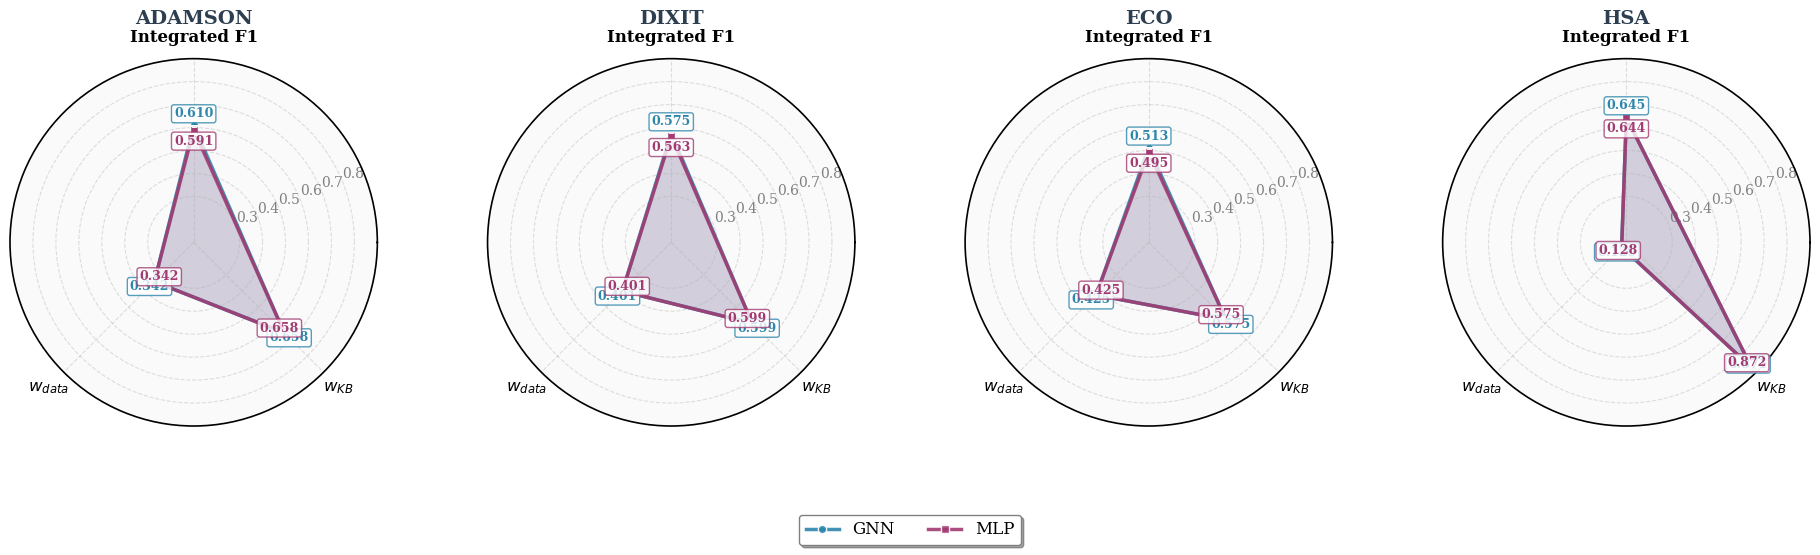

📊 Publication-quality plots saved as 'radar_plots_publication.pdf' and 'radar_plots_publication.png'

PUBLICATION SUMMARY: Algorithm Performance Across Datasets

Table 1: Performance comparison across datasets
-----------------------------------------------------------------
Dataset    GNN F1   MLP F1   Improve   w_data   w_KB    
-----------------------------------------------------------------
ADAMSON    0.610    0.591    +3.2%     0.342    0.658   
DIXIT      0.575    0.563    +2.1%     0.401    0.599   
ECO        0.513    0.495    +3.7%     0.425    0.575   
HSA        0.645    0.644    +0.1%     0.129    0.871   


In [3]:
# Create radar plot visualizations with publication-quality styling
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'font.size': 11,
    'font.family': 'serif',
    # 'font.serif': ['Times New Roman'],
    'axes.linewidth': 1.2,
    'axes.spines.left': True,
    'axes.spines.bottom': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'xtick.major.size': 5,
    'xtick.minor.size': 3,
    'ytick.major.size': 5,
    'ytick.minor.size': 3,
    'legend.frameon': True,
    'legend.fancybox': True,
    'legend.shadow': True,
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": r"\usepackage[utf8]{inputenc}\usepackage[T1]{fontenc}",
})

def create_radar_plot(ax, dataset_name, gnn_values, mlp_values, categories):
    """Create a publication-quality radar plot for one dataset comparing GNN and MLP"""
    gnn_color = '#2E86AB'  # Professional blue
    mlp_color = '#A23B72'  # Professional magenta
    
    # Number of variables
    N = len(categories)
    
    # Set specific angles: 90°, 225°, 315° (converted to radians)
    angles = [np.pi/2, 5*np.pi/4, 7*np.pi/4]  # 90°, 225°, 315° in radians
    angles += angles[:1]  # Complete the circle
    
    # Add values to complete the circle
    gnn_values += gnn_values[:1]
    mlp_values += mlp_values[:1]
    
    # Plot GNN with enhanced styling
    ax.plot(angles, gnn_values, 'o-', linewidth=2.5, label='GNN', 
            color=gnn_color, alpha=0.9, markersize=6, markerfacecolor=gnn_color, 
            markeredgecolor='white', markeredgewidth=1)
    ax.fill(angles, gnn_values, alpha=0.15, color=gnn_color)
    
    # Plot MLP with enhanced styling
    ax.plot(angles, mlp_values, 's-', linewidth=2.5, label='MLP', 
            color=mlp_color, alpha=0.9, markersize=6, markerfacecolor=mlp_color,
            markeredgecolor='white', markeredgewidth=1)
    ax.fill(angles, mlp_values, alpha=0.15, color=mlp_color)
    
    # Enhanced category labels
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(categories, fontsize=12, fontweight='bold')
    
    # Set y-axis limits and labels with better formatting (extend to accommodate HSA data)
    ax.set_ylim(0.1, 0.9)
    ax.set_yticks([0.3, 0.4, 0.5, 0.6, 0.7, 0.8])
    ax.set_yticklabels(['0.3', '0.4', '0.5', '0.6', '0.7', '0.8'], 
                       fontsize=10, color='gray')
    
    # Enhanced grid
    ax.grid(True, alpha=0.4, linewidth=0.8, linestyle='--')
    ax.set_facecolor('#FAFAFA')  # Light background
    
    # Professional title
    ax.set_title(f'{dataset_name.upper()}', size=14, fontweight='bold', 
                pad=25, color='#2C3E50')
    
    # Enhanced value annotations with safe positioning
    for i, (angle, gnn_val, mlp_val) in enumerate(zip(angles[:-1], gnn_values[:-1], mlp_values[:-1])):
        # Ensure values are finite and within reasonable bounds
        if not (np.isfinite(gnn_val) and np.isfinite(mlp_val)):
            continue
            
        # Position annotations more strategically
        if angle == np.pi/2:  # Top position (F1)
            gnn_offset, mlp_offset = 0.05, -0.05
        else:  # Bottom positions
            gnn_offset, mlp_offset = 0.03, -0.03
        
        # Clamp annotation positions to visible area
        gnn_text_pos = min(gnn_val + gnn_offset, 0.85)
        mlp_text_pos = max(mlp_val + mlp_offset, 0.15)
        
        # GNN values with background box
        if gnn_val <= 0.9:  # Only show annotation if within extended range
            ax.text(angle, gnn_text_pos, f'{gnn_val:.3f}', 
                    ha='center', va='center', fontsize=9, color=gnn_color, 
                    fontweight='bold', bbox=dict(boxstyle="round,pad=0.2", 
                    facecolor='white', alpha=0.8, edgecolor=gnn_color, linewidth=1))
        
        # MLP values with background box
        if mlp_val <= 0.9:  # Only show annotation if within extended range
            ax.text(angle, mlp_text_pos, f'{mlp_val:.3f}', 
                    ha='center', va='center', fontsize=9, color=mlp_color, 
                    fontweight='bold', bbox=dict(boxstyle="round,pad=0.2", 
                    facecolor='white', alpha=0.8, edgecolor=mlp_color, linewidth=1))

# Create publication-quality radar plots
fig = plt.figure(figsize=(20, 5.5))
fig.patch.set_facecolor('white')

# Define categories with improved labels
categories = ['Integrated F1', r'$w_{data}$', r'$w_{KB}$']

# Get datasets that have data for both GNN and MLP
available_datasets = []
for dataset in f1_pivot.index:
    if pd.notna(f1_pivot.loc[dataset, 'GNN']) and pd.notna(f1_pivot.loc[dataset, 'MLP']):
        available_datasets.append(dataset)

n_datasets = len(available_datasets)
if n_datasets > 0:
    # Create subplot for each dataset with improved spacing
    for i, dataset in enumerate(available_datasets):
        ax = fig.add_subplot(1, n_datasets, i+1, projection='polar')
        
        # Get values for this dataset
        gnn_values = [
            f1_pivot.loc[dataset, 'GNN'],
            wdata_pivot.loc[dataset, 'GNN'], 
            wklg_pivot.loc[dataset, 'GNN']
        ]
        
        mlp_values = [
            f1_pivot.loc[dataset, 'MLP'],
            wdata_pivot.loc[dataset, 'MLP'],
            wklg_pivot.loc[dataset, 'MLP'] 
        ]
        
        create_radar_plot(ax, dataset, gnn_values, mlp_values, categories)

    # Add a single legend for all subplots
    handles, labels = ax.get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.02), 
               ncol=2, fontsize=12, frameon=True, fancybox=True, shadow=True,
               facecolor='white', edgecolor='gray')

else:
    print("No datasets with complete data found for radar plots")

# Adjust layout with proper spacing
plt.subplots_adjust(top=0.85, bottom=0.15, left=0.05, right=0.95, wspace=0.3)
plt.show()

# Save high-resolution version for publication
fig.savefig('radar_plots_publication.pdf', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
fig.savefig('radar_plots_publication.png', dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

print("📊 Publication-quality plots saved as 'radar_plots_publication.pdf' and 'radar_plots_publication.png'")

# Create summary table for publication
print("\n" + "="*80)
print("PUBLICATION SUMMARY: Algorithm Performance Across Datasets")
print("="*80)

# Create a professional summary table
summary_table = []
for dataset in available_datasets:
    gnn_f1 = f1_pivot.loc[dataset, 'GNN']
    mlp_f1 = f1_pivot.loc[dataset, 'MLP']
    gnn_wdata = wdata_pivot.loc[dataset, 'GNN']
    gnn_wklg = wklg_pivot.loc[dataset, 'GNN']
    improvement = ((gnn_f1 - mlp_f1) / mlp_f1) * 100
    
    summary_table.append([
        dataset.upper(),
        f"{gnn_f1:.3f}",
        f"{mlp_f1:.3f}", 
        f"{improvement:+.1f}%",
        f"{gnn_wdata:.3f}",
        f"{gnn_wklg:.3f}"
    ])

# Print formatted table
import pandas as pd
summary_df = pd.DataFrame(summary_table, columns=[
    'Dataset', 'GNN F1', 'MLP F1', 'Improvement', 'w_data', 'w_KB'
])

print("\nTable 1: Performance comparison across datasets")
print("-" * 65)
print(f"{'Dataset':<10} {'GNN F1':<8} {'MLP F1':<8} {'Improve':<9} {'w_data':<8} {'w_KB':<8}")
print("-" * 65)
for _, row in summary_df.iterrows():
    print(f"{row['Dataset']:<10} {row['GNN F1']:<8} {row['MLP F1']:<8} {row['Improvement']:<9} {row['w_data']:<8} {row['w_KB']:<8}")